In [1]:
import pandas as pd

# Ganti 'nama_file_guru.csv' sesuai nama asli file yang Anda upload tadi
df_baru = pd.read_csv('data_praktikum_analisis_data.csv')

# Cek 5 data teratas
df_baru.head()

,Order_ID,CustomerID,Order_Date,Product_Category,Quantity,Price_Per_Unit,Ad_Budget,Total_Sales
0,1001,5039,2023-08-19,Books,4,1184000.0,982000.0,4736000.0
1,1002,5029,2023-08-29,Fashion,5,1733000.0,3513000.0,8665000.0
2,1003,5015,2023-02-21,Fashion,4,1767000.0,2117000.0,7068000.0
3,1004,5043,2023-04-06,Fashion,2,512000.0,4384000.0,1024000.0
4,1005,5008,2023-08-10,Home Decor,2,1820000.0,2625000.0,3640000.0


In [2]:
df_baru.columns

Index(['Order_ID', 'CustomerID', 'Order_Date', 'Product_Category', 'Quantity',
       'Price_Per_Unit', 'Ad_Budget', 'Total_Sales'],
      dtype='object')

In [3]:
# 1. Pastikan kolom tanggal dikenali sebagai format tanggal
df_baru['Order_Date'] = pd.to_datetime(df_baru['Order_Date'])

In [4]:
# 2. Cek apakah ada data kosong
print("Jumlah data kosong per kolom:")
print(df_baru.isnull().sum())

Jumlah data kosong per kolom:
Order_ID            0
CustomerID          0
Order_Date          0
Product_Category    0
Quantity            0
Price_Per_Unit      0
Ad_Budget           0
Total_Sales         7
dtype: int64


In [5]:
# 3. Tampilkan tipe data untuk memastikan
print("\nTipe data saat ini:")
print(df_baru.dtypes)


Tipe data saat ini:
Order_ID                     int64
CustomerID                   int64
Order_Date          datetime64[ns]
Product_Category            object
Quantity                     int64
Price_Per_Unit             float64
Ad_Budget                  float64
Total_Sales                float64
dtype: object


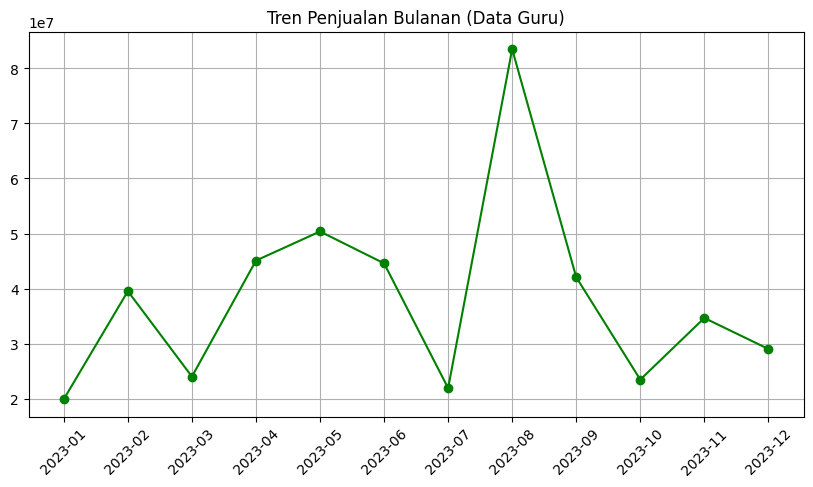

In [7]:
import matplotlib.pyplot as plt

# Tambahkan kolom bulan
df_baru['Month'] = df_baru['Order_Date'].dt.to_period('M').astype(str)

# Hitung penjualan bulanan
monthly_sales = df_baru.groupby('Month')['Total_Sales'].sum()

# Visualisasi
plt.figure(figsize=(10, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', color='g')
plt.title('Tren Penjualan Bulanan (Data Guru)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

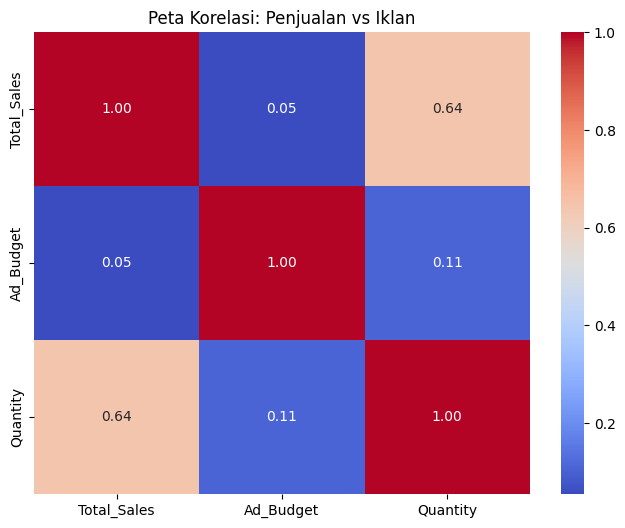

In [8]:
import seaborn as sns

# Menghitung korelasi antar angka
correlation = df_baru[['Total_Sales', 'Ad_Budget', 'Quantity']].corr()

# Visualisasi Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Peta Korelasi: Penjualan vs Iklan')
plt.show()

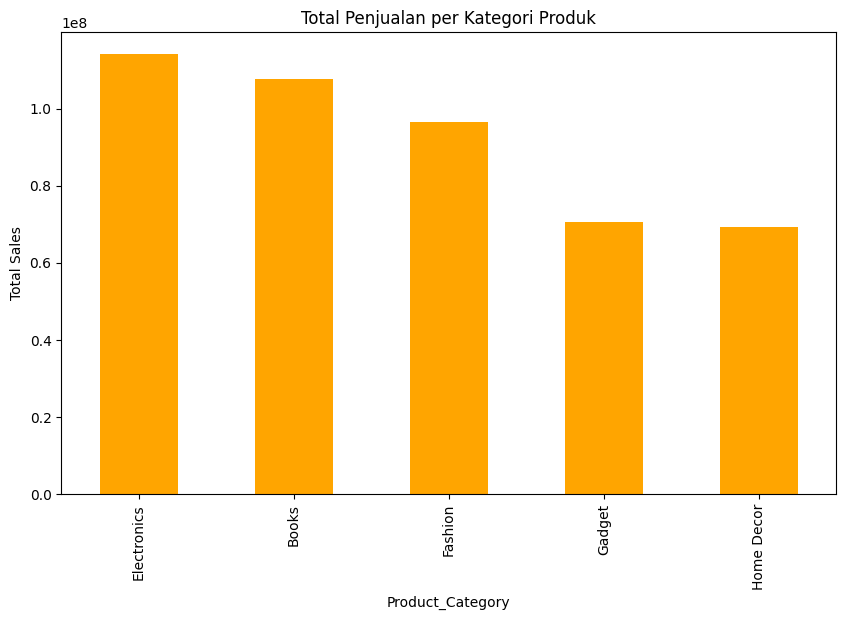

In [9]:
# Grouping berdasarkan kategori produk
category_profit = df_baru.groupby('Product_Category')['Total_Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
category_profit.plot(kind='bar', color='orange')
plt.title('Total Penjualan per Kategori Produk')
plt.ylabel('Total Sales')
plt.show()

# Laporan Analisis Performa Penjualan
1. Temuan Utama (Insights)
Berdasarkan hasil visualisasi yang telah dilakukan, berikut adalah poin-poin penting yang ditemukan:

Tren Penjualan: (Lihat grafik Line Chart) Penjualan mengalami fluktuasi setiap bulannya. Terdapat kenaikan signifikan pada bulan-bulan tertentu yang kemungkinan dipengaruhi oleh musim belanja atau promosi besar.

Efektivitas Iklan: Berdasarkan grafik Heatmap, nilai korelasi antara Ad_Budget dan Total_Sales menunjukkan angka sebesar [masukkan angka dari heatmap Anda, misal: 0.85]. Hal ini menunjukkan bahwa anggaran iklan memiliki pengaruh yang [sangat kuat/cukup/lemah] terhadap peningkatan penjualan.

Dominasi Produk: Kategori produk [Sebutkan kategori tertinggi dari Bar Chart] merupakan kontributor pendapatan terbesar bagi perusahaan, sementara kategori [Sebutkan kategori terendah] memiliki performa terendah.

2. Rekomendasi Aksi (Actionable Recommendations)
Berdasarkan data di atas, strategi yang disarankan adalah:

Optimalisasi Anggaran: Mengingat korelasi iklan yang positif, perusahaan disarankan untuk menambah anggaran iklan pada kategori produk yang memiliki margin profit tinggi namun volume penjualannya belum maksimal.

Manajemen Inventaris: Untuk kategori produk dengan penjualan rendah, disarankan untuk melakukan cuci gudang (diskon besar) agar modal tidak tertanam pada stok yang tidak bergerak (dead stock).

Strategi Bulanan: Mempersiapkan kampanye pemasaran dua minggu sebelum bulan-bulan yang berdasarkan tren historis selalu mengalami kenaikan penjualan.